In [12]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ============================================================
# Dataset
# x0 ~ N(10, 2)
# ============================================================

mu = 10.0
var = 2.0

N = 10000

x0_np = np.random.normal(
    mu,
    np.sqrt(var),
    N
).astype(np.float32)

x0_train = torch.tensor(x0_np).view(-1, 1)

# ============================================================
# Different sigmas
# ============================================================

sigmas = [0.3, 0.5, 1.0, 2.0, 3.0]

# ============================================================
# Record results
# ============================================================

final_ESM = []
final_ISM = []
final_DSM = []
final_IDSM = []

theory_ISM = []
theory_DSM = []

# ============================================================
# Loop over sigmas
# ============================================================
models = {}
for sigma in sigmas:

    print(f"\n========== sigma = {sigma} ==========")

    # ========================================================
    # Model
    # ========================================================

    class ScoreNet(nn.Module):

        def __init__(self):

            super().__init__()

            self.net = nn.Sequential(
                nn.Linear(1, 64),
                nn.SiLU(),

                nn.Linear(64, 64),
                nn.SiLU(),

                nn.Linear(64, 1)
            )

        def forward(self, x):
            return self.net(x)

    model = ScoreNet()

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    # ========================================================
    # Training
    # ========================================================

    epochs = 3000

    x0_train.requires_grad_(True)
    
    
    for epoch in range(epochs):

        # ----------------------------------------------------
        # noisy sample
        # x = x0 + sigma * epsilon
        # ----------------------------------------------------

        epsilon = torch.randn_like(x0_train)

        x_noisy = x0_train + sigma * epsilon

        x_noisy.requires_grad_(True)

        # ----------------------------------------------------
        # scores
        # ----------------------------------------------------

        # marginal score
        # p_sigma(x) = N(mu, var + sigma^2)

        marginal_score = (
            -(x_noisy - mu)
            / (var + sigma**2)
        )

        # conditional score
        # p(x|x0)

        conditional_score = (
            -(x_noisy - x0_train)
            / (sigma**2)
        )

        # model prediction

        pred_score = model(x_noisy)

        # ====================================================
        # 1. L_ESM
        # ====================================================

        L_ESM = (
            (pred_score - marginal_score)**2
        ).mean()

        # ====================================================
        # 2. L_ISM
        # ====================================================

        div_score = torch.autograd.grad(
            outputs=pred_score.sum(),
            inputs=x_noisy,
            create_graph=True
        )[0]

        L_ISM = (
            pred_score**2
            + 2 * div_score
        ).mean()

        # ====================================================
        # 3. L_DSM
        # ====================================================

        term1 = (marginal_score**2).mean()

        term2 = (conditional_score**2).mean()

        L_DSM = (
            L_ESM
            - term1
            + term2
        )

        # ====================================================
        # 4. I_DSM
        # ====================================================

        I_DSM = (
            pred_score**2
            - pred_score * conditional_score
        ).mean()

        # ====================================================
        # Train
        # ====================================================

        loss = L_ESM

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        models[sigma] = model

        if epoch % 300 == 0:

            print(
                f"Epoch {epoch:4d} | "
                f"L_ESM = {L_ESM.item():.8f} | "
                f"L_ISM = {L_ISM.item():.8f} | "
                f"L_DSM = {L_DSM.item():.8f} | "
                f"I_DSM = {I_DSM.item():.8f}"
            )

    # ========================================================
    # Final values
    # ========================================================

    final_ESM.append(L_ESM.item())
    final_ISM.append(L_ISM.item())
    final_DSM.append(L_DSM.item())
    final_IDSM.append(I_DSM.item())

    # ========================================================
    # Theory
    # ========================================================

    theory_ism = -1 / (var + sigma**2)

    theory_dsm = (
        1 / sigma**2
        - 1 / (var + sigma**2)
    )

    theory_ISM.append(theory_ism)
    theory_DSM.append(theory_dsm)

    



========== sigma = 0.3 ==========
Epoch    0 | L_ESM = 0.85596877 | L_ISM = 0.36143181 | L_DSM = 11.59933472 | I_DSM = 0.30480459
Epoch  300 | L_ESM = 0.00023670 | L_ISM = -0.47559518 | L_DSM = 10.65879345 | I_DSM = -0.04583466
Epoch  600 | L_ESM = 0.00126126 | L_ISM = -0.48147851 | L_DSM = 10.61610222 | I_DSM = 0.05141965
Epoch  900 | L_ESM = 0.00010682 | L_ISM = -0.47921354 | L_DSM = 10.48250484 | I_DSM = -0.00478291
Epoch 1200 | L_ESM = 0.00170445 | L_ISM = -0.47255370 | L_DSM = 10.78119469 | I_DSM = -0.04043195
Epoch 1500 | L_ESM = 0.00021398 | L_ISM = -0.47889078 | L_DSM = 10.53624249 | I_DSM = 0.00051493
Epoch 1800 | L_ESM = 0.00003720 | L_ISM = -0.47860932 | L_DSM = 10.59573174 | I_DSM = -0.01387025
Epoch 2100 | L_ESM = 0.00014751 | L_ISM = -0.48122188 | L_DSM = 10.79525280 | I_DSM = 0.01755849
Epoch 2400 | L_ESM = 0.00002345 | L_ISM = -0.47688681 | L_DSM = 10.60952091 | I_DSM = -0.03315983
Epoch 2700 | L_ESM = 0.00001863 | L_ISM = -0.47817686 | L_DSM = 10.56466484 | I_DSM = -0

# Loss, Indicator圖

In [13]:
all_values = (
    final_ESM
    + final_ISM
    + final_DSM
    + final_IDSM
    + theory_ISM
    + theory_DSM
)

ymin = min(all_values) - 3.0
ymax = max(all_values) + 0.1

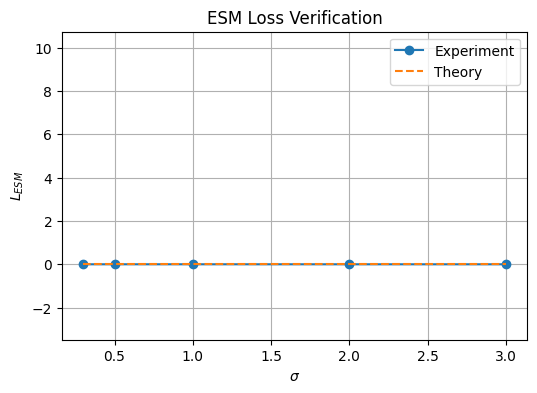

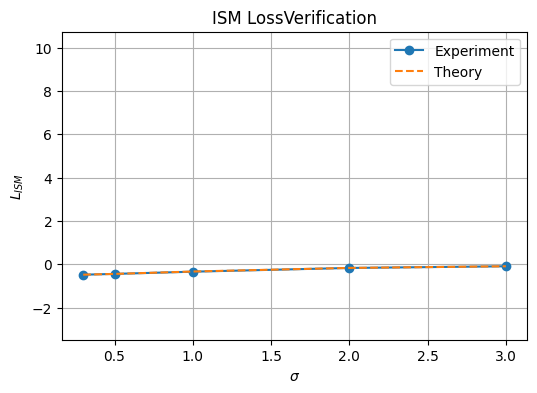

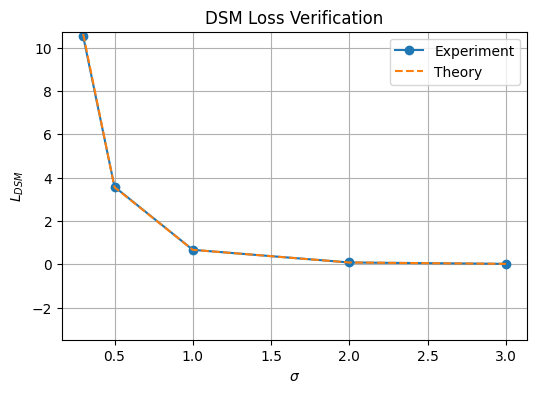

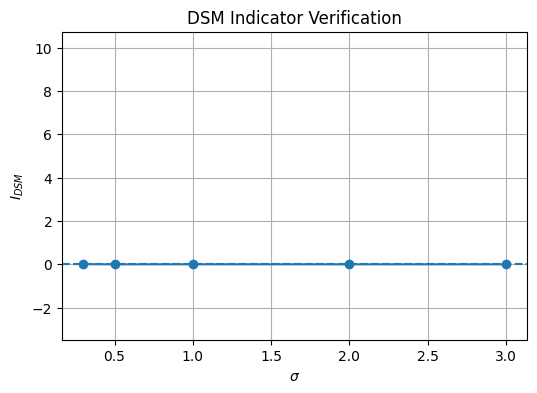

In [14]:
# ============================================================
# Plot ESM
# ============================================================

theory_ESM = [0 for sigma in sigmas]

plt.figure(figsize=(6,4))

plt.plot(
    sigmas,
    final_ESM,
    'o-',
    label='Experiment'
)

plt.plot(
    sigmas,
    theory_ESM,
    '--',
    label='Theory'
)
plt.ylim(ymin, ymax)
plt.xlabel(r'$\sigma$')
plt.ylabel(r'$L_{ESM}$')

plt.title("ESM Loss Verification")

plt.legend()
plt.grid(True)

plt.show()
# ============================================================
# Plot ISM
# ============================================================

plt.figure(figsize=(6,4))

plt.plot(
    sigmas,
    final_ISM,
    'o-',
    label='Experiment'
)

plt.plot(
    sigmas,
    theory_ISM,
    '--',
    label='Theory'
)
plt.ylim(ymin, ymax)
plt.xlabel(r'$\sigma$')
plt.ylabel(r'$L_{ISM}$')

plt.title("ISM LossVerification")

plt.legend()
plt.grid(True)

plt.show()

# ============================================================
# Plot DSM
# ============================================================

plt.figure(figsize=(6,4))

plt.plot(
    sigmas,
    final_DSM,
    'o-',
    label='Experiment'
)

plt.plot(
    sigmas,
    theory_DSM,
    '--',
    label='Theory'
)
plt.ylim(ymin, ymax)
plt.xlabel(r'$\sigma$')
plt.ylabel(r'$L_{DSM}$')

plt.title("DSM Loss Verification")

plt.legend()
plt.grid(True)

plt.show()

# ============================================================
# Plot I_DSM
# ============================================================

plt.figure(figsize=(6,4))

plt.plot(
    sigmas,
    final_IDSM,
    'o-'
)

plt.axhline(
    0,
    linestyle='--'
)
plt.ylim(ymin, ymax)
plt.xlabel(r'$\sigma$')
plt.ylabel(r'$I_{DSM}$')

plt.title("DSM Indicator Verification")

plt.grid(True)

plt.show()

# Denoised 分布

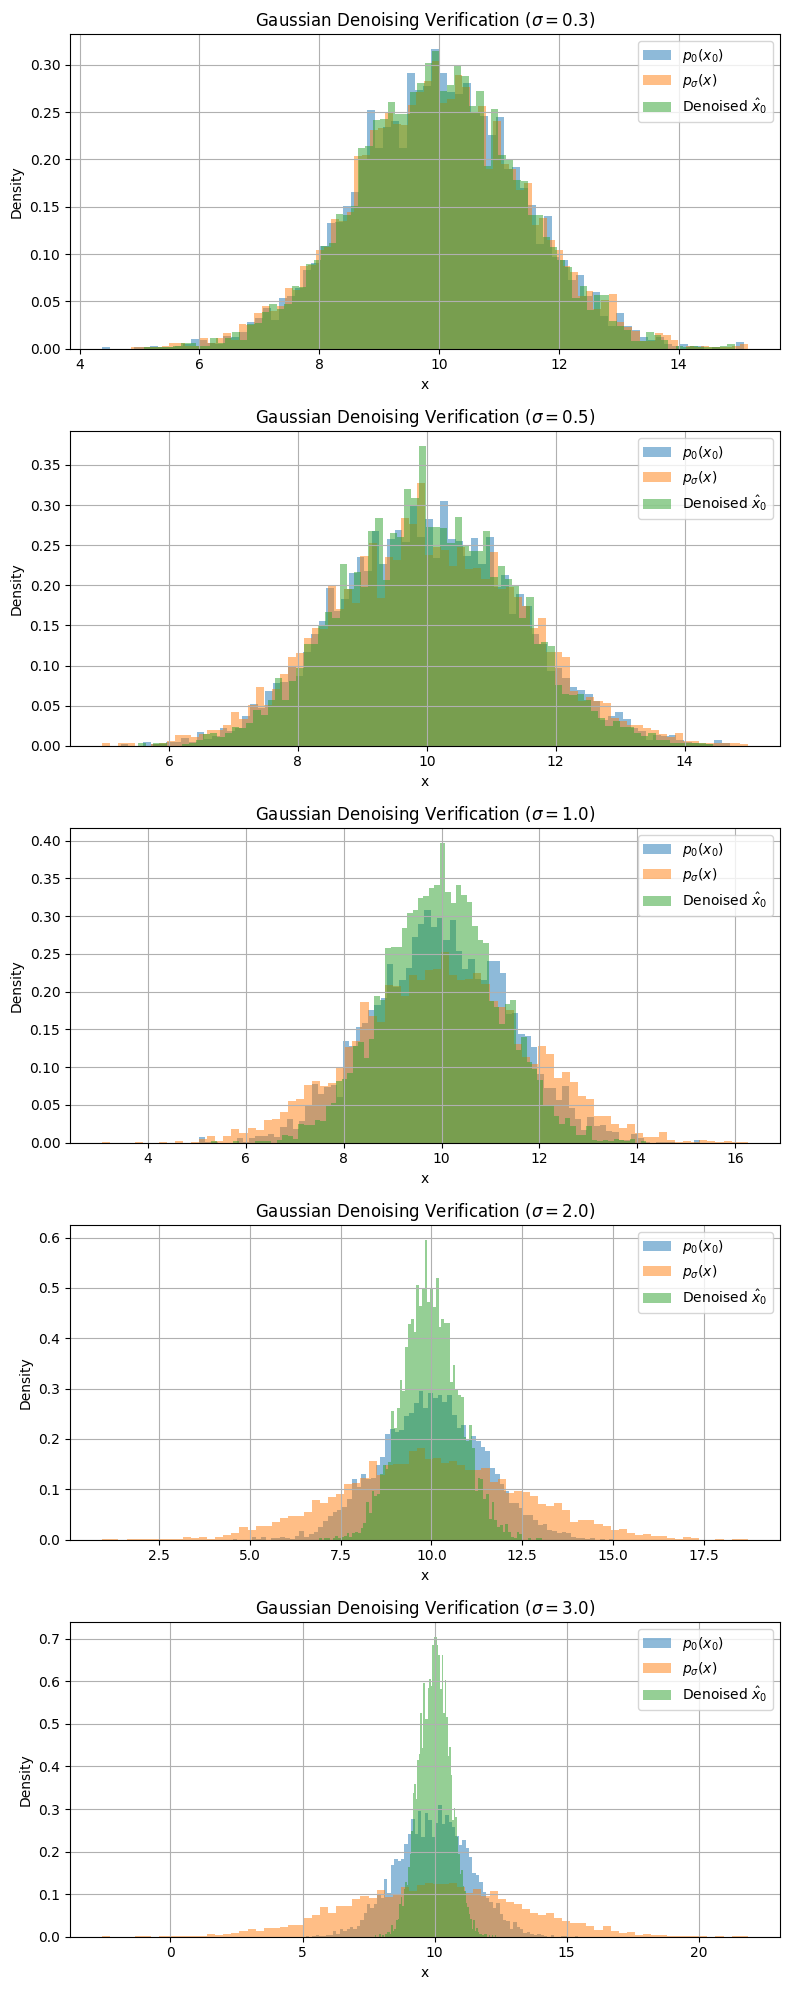

In [16]:
# ============================================================
# Compare distributions for different sigmas
# ============================================================

sigmas_plot = [0.3, 0.5, 1.0, 2.0, 3.0]

fig, axes = plt.subplots(
    len(sigmas_plot),
    1,
    figsize=(8, 4 * len(sigmas_plot))
)

for idx, sigma in enumerate(sigmas_plot):

    # --------------------------------------------------------
    # x0 distribution
    # --------------------------------------------------------

    x0_true = np.random.normal(
        mu,
        np.sqrt(var),
        5000
    )

    # --------------------------------------------------------
    # noisy distribution
    # x = x0 + sigma * epsilon
    # --------------------------------------------------------

    epsilon = np.random.randn(5000)

    x_noisy = x0_true + sigma * epsilon

    # --------------------------------------------------------
    # denoise by Tweedie formula
    # x0_hat = x + sigma^2 * score(x)
    # --------------------------------------------------------

    x_tensor = torch.tensor(
        x_noisy,
        dtype=torch.float32
    ).view(-1,1)

    with torch.no_grad():

        score = models[sigma](x_tensor)

        x0_hat = (
            x_tensor
            + sigma**2 * score
        )

    x0_hat = x0_hat.numpy().flatten()

    # --------------------------------------------------------
    # plot
    # --------------------------------------------------------

    ax = axes[idx]

    ax.hist(
        x0_true,
        bins=80,
        density=True,
        alpha=0.5,
        label=r'$p_0(x_0)$'
    )

    ax.hist(
        x_noisy,
        bins=80,
        density=True,
        alpha=0.5,
        label=r'$p_\sigma(x)$'
    )

    ax.hist(
        x0_hat,
        bins=80,
        density=True,
        alpha=0.5,
        label=r'Denoised $\hat{x}_0$'
    )

    ax.set_title(
        rf'Gaussian Denoising Verification ($\sigma={sigma}$)'
    )

    ax.set_xlabel('x')
    ax.set_ylabel('Density')

    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()